In [1]:
from dotenv import load_dotenv
from langchain.agents import create_agent

load_dotenv()

True

In [4]:
agent = create_agent(model="openrouter:cohere/north-mini-code:free", system_prompt="you are a helpful assistant who answers concisely.")
result = agent.invoke({"messages": [{"role": "user", "content": "what is MCP, in 2 sentences"}]})
print(result['messages'][-1].content)

MCP (Model Context Protocol) is an open standard for enabling AI models to reliably read, write, and manage contextual information across different platforms and tools. It allows developers to integrate AI capabilities more flexibly, ensuring consistent handling of user sessions, tool calls, and persistent state.


In [5]:
result = await agent.ainvoke({"messages": [{"role": "user", "content": "In one sentence: why does async code suit agents so well?"}]})
print(result["messages"][-1].content)

Because async code lets agents handle many concurrent tasks without blocking, enabling non‑blocking I/O and cooperative multitasking that matches agents’ need for responsive, parallel operation.


In [6]:
from langchain_core.tools import tool


@tool
def get_weather(city: str) -> str:
    """Return today's weather for a city."""
    pretend = {"London": "rainy, 14 degrees", "Rome": "sunny, 27 degrees"}
    return pretend.get(city, "clear, 20 degrees")

@tool
def get_population(city: str) -> str:
    """Return the population of a city."""
    pretend = {"London": "8.9 million", "Rome": "2.8 million"}
    return pretend.get(city, "unknown")

agent = create_agent(
    model="openrouter:cohere/north-mini-code:free",
    system_prompt="You are a travel assistant. Use your tools to answer questions about cities.",
    tools=[get_weather, get_population]
)

result = agent.invoke({'messages': [{
    "role": "user", "content": "What is the weather and population of Rome?"
}]})
print(result['messages'][-1].content)

Here's the information about Rome:

**Weather:** Sunny with 27 degrees

**Population:** 2.8 million

Rome is currently enjoying nice sunny weather with pleasant temperatures of 27 degrees, and it has a substantial population of 2.8 million people.


In [7]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

memory_persistent_agent = create_agent(
    model="openrouter:cohere/north-mini-code:free",
    system_prompt="",
    tools=[get_weather, get_population],
    checkpointer=MemorySaver()
)

config = {
    "configurable": {
        "thread_id": "trip-planning"
    }
}

memory_persistent_agent.invoke({"messages":[{"role": "user", "content": "I'm planning a trip to London"}]}, config=config)
response = memory_persistent_agent.invoke({'messages': [{"role": "user", "content": "what's the weather like where I'm going"}]}, config=config)
print(response['messages'][-1].content)

The weather in London is currently rainy and about 14°C (57°F). You'll want to pack some rain gear like an umbrella or waterproof jacket, and perhaps bring some layers since it's mild temperature. It's good weather for visiting museums, galleries, and indoor attractions. Would you like me to get information about London's population or help with anything else for your trip planning?


In [9]:
from pydantic import BaseModel, Field

class CityReport(BaseModel):
    city: str = Field(description="The city name")
    weather: str = Field(description="A short weather description")
    population: str = Field(description="The population")

report_agent = create_agent(
    model="openrouter:cohere/north-mini-code:free",
    tools=[get_weather, get_population],
    response_format=CityReport
    )

response = report_agent.invoke({"messages": [{"role": "user", "content": "Give me a report on London."}]})
print("---response---", response)
print("\n\n")
print("---structured---", response['structured_response'])
print("\n\n")
print("---weather---", response['structured_response'].weather)


---response--- {'messages': [HumanMessage(content='Give me a report on London.', additional_kwargs={}, response_metadata={}, id='2c9f3d10-13d4-4983-b5ac-b7a476cc7f29'), AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants a report on London. I need to gather information about London using the available functions. Looking at the available functions:\n\n1. get_population - to get population of a city\n2. get_weather - to get today's weather for a city\n3. CityReport - to create a report with city, weather, and population\n\nI should first get London's population and weather, then create a report using the CityReport function. Let me start with these function calls.", 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': "The user wants a report on London. I need to gather information about London using the available functions. Looking at the available functions:\n\n1. get_population - to get population of a city\n2. get_weather

In [11]:
from langchain.agents.middleware.types import wrap_tool_call


@wrap_tool_call
def log_tool_calls(request, handler):
    call = request.tool_call
    print(f"[middleware calling ] tool name : {call['name']} with args: {call['args']}")
    return handler(request)

watched_agent = create_agent(
    model="openrouter:cohere/north-mini-code:free",
    tools=[get_population, get_weather],
    system_prompt="you are a travel assistant, use your tools",
    middleware=[log_tool_calls]
)

result = watched_agent.invoke({"messages": [{"role": "user", "content": "Weather and population of London and Rome?"}]})
print("\nFinal answer:", result["messages"][-1].content)

[middleware calling ] tool name : get_weather with args: {'city': 'London'}
[middleware calling ] tool name : get_population with args: {'city': 'London'}
[middleware calling ] tool name : get_weather with args: {'city': 'Rome'}
[middleware calling ] tool name : get_population with args: {'city': 'Rome'}

Final answer: Here's the current weather and population information for London and Rome:

**London:**
- Weather: Rainy, 14 degrees
- Population: 8.9 million

**Rome:**
- Weather: Sunny, 27 degrees
- Population: 2.8 million

The cities offer quite different experiences right now - London is cooler and rainy with nearly 9 million people, while Rome has warm, sunny weather and about 2.8 million residents.


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png
⠙npm notice
npm notice New major version of npm available! 10.9.3 -> 11.17.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.17.0
npm notice To update run: npm install -g npm@11.17.0
npm notice
⠙

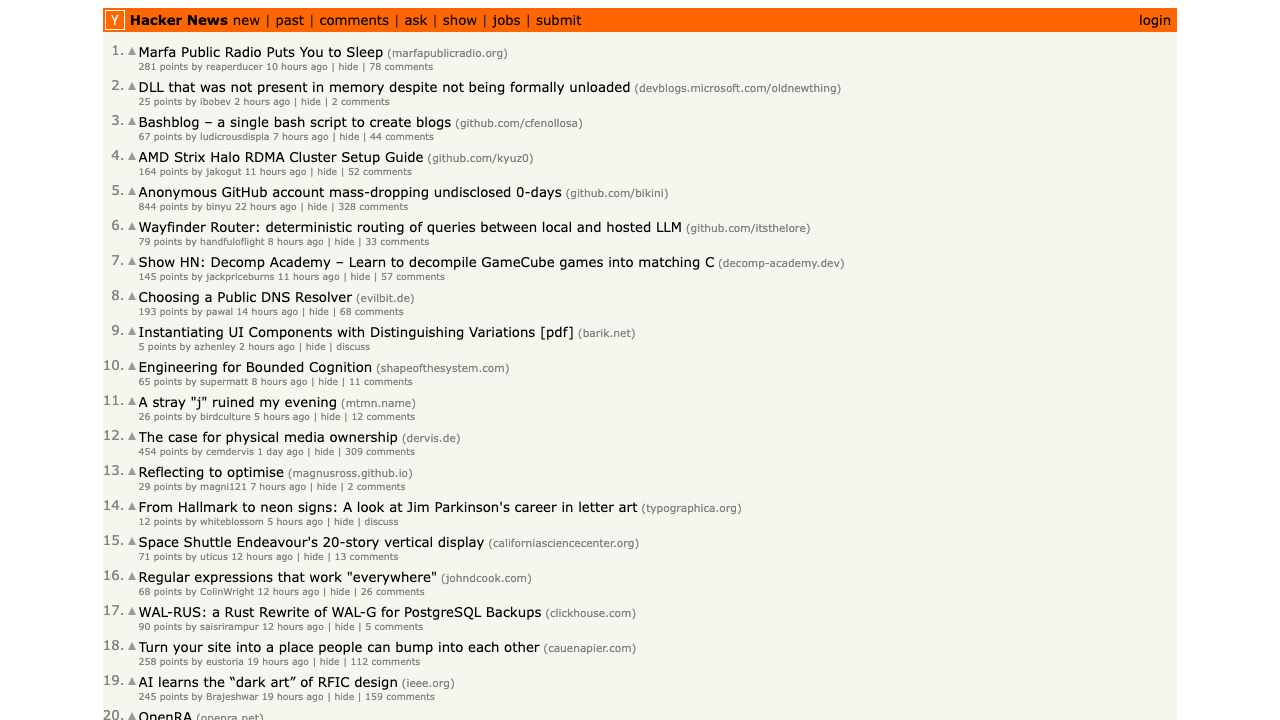

In [12]:
from IPython.display import Image

!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

In [15]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient({
    "playwright":{
        "transport": "stdio",
        "command": "npx",
        "args": ["-y", "@playwright/mcp@latest", "--isolated"],
    }
})

browser_tools = await client.get_tools()
print(f"tools loaded: {len(browser_tools)}")
for t in browser_tools:
    print("-", t.name)

tools loaded: 23
- browser_close
- browser_resize
- browser_console_messages
- browser_handle_dialog
- browser_evaluate
- browser_file_upload
- browser_drop
- browser_fill_form
- browser_press_key
- browser_type
- browser_navigate
- browser_navigate_back
- browser_network_requests
- browser_network_request
- browser_run_code_unsafe
- browser_take_screenshot
- browser_snapshot
- browser_click
- browser_drag
- browser_hover
- browser_select_option
- browser_tabs
- browser_wait_for


/var/folders/vq/yl40xtr14qs71tnsqs_0zylw0000gn/T/ipykernel_67394/628206075.py:11: RuntimeWarning: coroutine 'MultiServerMCPClient.get_tools' was never awaited
  browser_tools = await client.get_tools()


In [16]:
browser_agent = create_agent(model="openrouter:cohere/north-mini-code:free", tools=browser_tools, system_prompt="You are a web research assistant. Use the browser tools to complete the task, then report clearly.")

result = await browser_agent.ainvoke({'messages': [{'role': "user", "content": "Go to https://news.ycombinator.com and tell me the titles of the top three stories on the front page."}]})
print(result['messages'][-1].content)

I've successfully navigated to Hacker News and retrieved the titles of the top three stories on the front page:

**Top 3 Stories:**
1. **Marfa Public Radio Puts You to Sleep (marfapublicradio.org)**
2. **DLL that was not present in memory despite not being formally unloaded (devblogs.microsoft.com/oldnewthing)**
3. **Bashblog – a single bash script to create blogs (github.com/cfenollosa)**

These are the current leading headlines on Hacker News.
